In [15]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn;
import torch.optim as optim
import tqdm
torch.set_default_tensor_type(torch.DoubleTensor)

In [16]:
#no Sigma=>no g3|| with Omega4=> c3
class FindPar_RMF(nn.Module):
    def __init__(self,device,rho_p,rho_n,modelpar):
        super(FindPar_RMF,self).__init__()
        self.device=device
        self.rho_p=rho_p
        self.rho_n=rho_n
        #模型系数

        self.nucleonmass=torch.tensor(modelpar["M"])
        self.m_rho=torch.tensor(modelpar["m_rho"])
        self.m_omega=torch.tensor(modelpar["m_omega"])
        #be fitted
        self.m_sigma=nn.Parameter(torch.tensor(modelpar["m_sigma"]))
        self.g_sigma=nn.Parameter(torch.tensor(modelpar["g_sigma"]))
        self.g_omega=nn.Parameter(torch.tensor(modelpar["g_omega"]))
        self.g_rho=nn.Parameter(torch.tensor(modelpar["g_rho"]))
        self.g2=nn.Parameter(torch.tensor(modelpar["g2"]))
        self.c3=nn.Parameter(torch.tensor(modelpar["c3"]))
        
    
    def findsigma(self,rho_n,rho_p,startpoint=0.0,step=0.1,accuracy=4):
        #在迭代的时候可能会自动梯度下降到小于0的状态，所以要进行检查一下


        #设置精度：
        pointnum=rho_p.size()

        deltasigma=10000
        sigma=(torch.rand(pointnum)*startpoint).to(torch.device(self.device))
        cout=0
        while torch.sum(abs(deltasigma)>abs(sigma)*torch.pow(torch.tensor(0.1),accuracy))>0:

            m_n=self.nucleonmass+self.g_sigma*sigma
            t_np=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_p,1/3)/m_n
            t_nn=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_n,1/3)/m_n
            rho_ps=torch.pow(m_n,3)/torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*(0.5*(t_np*torch.pow(1+torch.pow(t_np,2),0.5)-torch.arcsinh(t_np)))
            rho_ns=torch.pow(m_n,3)/torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*(0.5*(t_nn*torch.pow(1+torch.pow(t_nn,2),0.5)-torch.arcsinh(t_nn)))
            newsigma=-(self.g2*torch.pow(sigma,2)+self.g_sigma*(rho_ns+rho_ps))/torch.pow(self.m_sigma,2)
            deltasigma=newsigma-sigma
            sigma=sigma+deltasigma*step
            cout=cout+1

        # print('sigma:cout=',cout)
        
        return sigma
    def findomega(self,rho_n,rho_p,startpoint=0.0,step=0.1,accuracy=4):
        #设置精度：
        pointnum=rho_p.size()

        deltaomega=10000
        omega=(torch.rand(pointnum)*startpoint).to(torch.device(self.device))
        cout=0
        while torch.sum(((abs(deltaomega))>abs(omega)*torch.pow(torch.tensor(0.1),accuracy)))>0:

            omeganew=(self.g_omega*(rho_p+rho_n)-self.c3*omega**3)/torch.pow(self.m_omega,2)
            deltaomega=omeganew-omega
            omega=omega+deltaomega*step
            cout=cout+1
            # print(omeganew)
        # print('omega:cout=',cout)
        return omega
    
    def findrho(self,rho_n,rho_p,startpoint=0.0,step=0.1,accuracy=4):
        #设置精度：
        pointnum=rho_p.size()

        deltarho=10000
        rho=(torch.rand(pointnum)*startpoint).to(torch.device(self.device))
        cout=0
        while torch.sum((abs(deltarho)>abs(rho)*torch.pow(torch.tensor(0.1),accuracy)))>0:
            

            rhonew=(self.g_rho*(rho_p-rho_n))/torch.pow(self.m_rho,2)
            deltarho=rhonew-rho
            rho=rho+deltarho*step
            cout=cout+1
            
        # print('rho:cout=',cout)
        return rho
    def EnergyDensity(self,rho_n,rho_p,step=0.1):
        sigma=self.findsigma(rho_n=rho_n,rho_p=rho_p,step=step)
        omega=self.findomega(rho_n=rho_n,rho_p=rho_p,step=step)
        rho=self.findrho(rho_n=rho_n,rho_p=rho_p,step=step)
        m_n=self.nucleonmass+self.g_sigma*sigma
        t_np=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_p,1/3)/m_n
        t_nn=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_n,1/3)/m_n
        a1=(t_np*torch.pow(torch.pow(t_np,2)+1,0.5)*(1+2*torch.pow(t_np,2))-torch.arcsinh(t_np))
        a2=(t_nn*torch.pow(torch.pow(t_nn,2)+1,0.5)*(1+2*torch.pow(t_nn,2))-torch.arcsinh(t_nn))

        eps=torch.pow(m_n,4)/(8*torch.pi**2)*(a1+a2)\
            +0.5*torch.pow(self.m_omega,2)*torch.pow(omega,2)+0.75*self.c3*torch.pow(omega,4)\
                +0.5*torch.pow(self.m_rho*rho,2)\
                    +0.5*torch.pow(self.m_sigma,2)*torch.pow(sigma,2)+1/3*self.g2*torch.pow(sigma,3)
        #--------debug------------#
        # print('eps:',eps)
        # print('partialsigma:',partialsigma)
        # print('partialomega:',partialomega)
        # print('partialrho:',partialrho)
        # print('partialA:',partialA)
        self.eps=eps
        return eps
    def calube(self):
        eps=self.EnergyDensity(self.rho_n,self.rho_p,step=0.1)
        xx=self.rho_p+self.rho_n
        be=eps/xx*100-self.nucleonmass*100
        be=be[1:]
        rho=xx[1:]
        return rho/1.97**3,be
    #输入的是fm-3 rho
    def optm_minrho(self,targetedrho=0.155):
        rho,be=self.calube()
        # 求导
        be_rightshifted1=torch.roll(be,1)
        be_leftshifted1=torch.roll(be,-1)
        begrad=(be_leftshifted1-be_rightshifted1)/2/(rho[1]-rho[0])
        rhoindex=torch.argmin(torch.abs(rho-targetedrho))
        index=torch.argmin(torch.abs(begrad))
        return begrad[rhoindex],be[index]
    
    def find_minrho(self):
        rho,be=self.calube()
        # 求导
        be_rightshifted1=torch.roll(be,1)
        be_leftshifted1=torch.roll(be,-1)
        begrad=(be_leftshifted1-be_rightshifted1)/2/(rho[1]-rho[0])
        index=torch.argmin(torch.abs(begrad))
        return rho[index],be[index]
    def Ksat(self,delta=0,deltastep=0.01,n0=0.16):
        n0=n0*1.97**3
        deltakai=deltastep
        kai=torch.tensor([-2*deltakai,-deltakai,0,deltakai,2*deltakai],device=self.device)
        rho_0=(3*kai*n0+n0)
        rho_p=((rho_0*delta)+rho_0)/2
        rho_n=((rho_0*delta)-rho_0)/-2
        eps=self.EnergyDensity(rho_n,rho_p,step=0.1)
        Ksat=(-eps[0]/rho_0[0]+16*eps[1]/rho_0[1]-30*eps[2]/rho_0[2]+16*eps[3]/rho_0[3]-eps[4]/rho_0[4])/12/(deltakai)/(deltakai)*100
        return Ksat 
    def esyms(self,kai=0,deltastep=0.01,n0=0.16):
        n0=n0*1.97**3
        rho_0=(3*kai*n0+n0)
        delta=(deltastep)/(rho_0)
        deltaarray=torch.tensor([-2*delta,-delta,0,delta,2*delta],device=self.device)
        
        rho_p=((rho_0*deltaarray)+rho_0)/2
        rho_n=((rho_0*deltaarray)-rho_0)/-2
        eps=self.EnergyDensity(rho_n,rho_p,step=0.1)
        esyms=0.5*(-eps[0]+16*eps[1]-30*eps[2]+16*eps[3]-eps[4])/12/(delta)/(delta)/(rho_0)*100
        return esyms 
    def Lsyms(self,kai=0,deltastep=0.01,n0=0.16):
        n0=n0*1.97**3
        delatakai=deltastep
        esyms1=self.esyms(kai=kai-delatakai,deltastep=delatakai)
        esyms2=self.esyms(kai=kai+delatakai,deltastep=delatakai)
        esyms3=self.esyms(kai=kai-2*delatakai,deltastep=delatakai)
        esyms4=self.esyms(kai=kai+2*delatakai,deltastep=delatakai)
        Lsyms=(-esyms4+8*esyms2-8*esyms1+esyms3)/12/(delatakai)
        return Lsyms


In [23]:
for e in netwdf.parameters():
    print(e)

Parameter containing:
tensor(5.2409, device='cuda:2', requires_grad=True)
Parameter containing:
tensor(9.6314, device='cuda:2', requires_grad=True)
Parameter containing:
tensor(11.5713, device='cuda:2', requires_grad=True)
Parameter containing:
tensor(3.1988, device='cuda:2', requires_grad=True)
Parameter containing:
tensor(-18.5885, device='cuda:2', requires_grad=True)
Parameter containing:
tensor(73.2072, device='cuda:2', requires_grad=True)


In [17]:


# modelpar={
#     "M":9.38,
#     "m_omega":7.83,
#     "m_rho":7.70,

#     "m_sigma":5.31,
#     "g_sigma":9.82,
#     "g_omega":11.8,
#     "g_rho":3.42,
#     "g2":-15.5,
#     "c3":72.6,
#     "electronmass":0.00511,
#     "echarge":0.303
# }
modelpar={
    "M":9.38,
    "m_omega":7.83,
    "m_rho":7.70,

    "m_sigma":5.2409,
    "g_sigma":9.6314,
    "g_omega":11.5713,
    "g_rho":3.1988,
    "g2":-18.5885,
    "c3":73.2072,
    "electronmass":0.00511,
    "echarge":0.303
}
# modelpar={
#     "M":9.38,
#     "m_sigma":8.8806,
#     "g2":-240.4207,
#     "g_sigma":13.8566,
#     "m_omega":36.4815,
#     "g_omega":38.9459,
#     "g_rho":24.3500,
#     "m_rho":51.2640,
#     "c3":72.6,
#     "electronmass":0.00511,
#     "echarge":0.303
# }
print(modelpar)


{'M': 9.38, 'm_omega': 7.83, 'm_rho': 7.7, 'm_sigma': 5.31, 'g_sigma': 9.82, 'g_omega': 11.8, 'g_rho': 3.42, 'g2': -15.5, 'c3': 72.6, 'electronmass': 0.00511, 'echarge': 0.303}


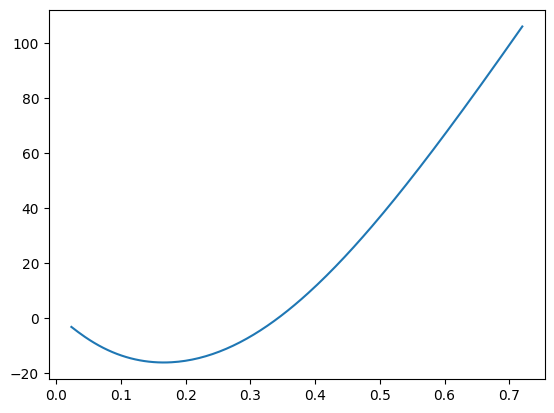

In [18]:
device='cuda:0' if torch.cuda.is_available() else 'cpu'
# device='cpu'
pointnum=200
rho_p=torch.linspace(0.01,0.36,pointnum,device=device)*1.97**3
rho_n=torch.linspace(0.01,0.36,pointnum,device=device)*1.97**3
# rho_n=torch.zeros(pointnum,device=device)
totalrho=rho_p+rho_n
# rho_p=netwdf.rho_p_rato
# rho_n=netwdf.rho_n_rato
netwdf=FindPar_RMF(device=device,rho_p=rho_p,rho_n=rho_n,modelpar=modelpar).to(torch.device(device))
# eps=netwdf.EnergyDensity()
# bindingenergy=eps*100/totalrho-938
nb,eps=netwdf.calube()
plt.plot(nb.cpu().numpy(),eps.cpu().detach().numpy())
# netwdf.find_minrho()
# netwdf.Ksat()
# netwdf.esyms()
# netwdf.Lsyms()



In [5]:

for e in netwdf.parameters():
    print(e)

Parameter containing:
tensor(8.8806, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-240.4207, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(13.8566, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(36.4815, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(38.9459, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(24.3500, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(51.2640, device='cuda:0', requires_grad=True)


In [22]:
print(netwdf.optm_minrho(0.15))
minrho,minbe=netwdf.find_minrho()
print("minrho",minrho)
print("minbe",minbe)
print("ksat",netwdf.Ksat())
print("esyms",netwdf.esyms())
print("Lsyms",netwdf.Lsyms())


(tensor(-4.8576, device='cuda:2', grad_fn=<SelectBackward0>), tensor(-15.2684, device='cuda:2', grad_fn=<SelectBackward0>))
minrho tensor(0.1537, device='cuda:2')
minbe tensor(-15.2684, device='cuda:2', grad_fn=<SelectBackward0>)
ksat tensor(259.5661, device='cuda:2', grad_fn=<MulBackward0>)
esyms tensor(27.6824, device='cuda:2', grad_fn=<MulBackward0>)
Lsyms tensor(81.0260, device='cuda:2', grad_fn=<DivBackward0>)


In [20]:
optm=optim.Adam(netwdf.parameters(), lr=0.5)
scheduler=torch.optim.lr_scheduler.ExponentialLR(optm, 0.9,last_epoch=-1)

In [21]:
#进行迭代
# optm=optim.Adam(netwdf.parameters(), lr=0.5)
for i in range(10000):
    losstotal=0
    for j in range(20):
        optm.zero_grad()
        lossf=nn.MSELoss()
        gradat,minbe=netwdf.optm_minrho()
        ksat=netwdf.Ksat()
        esyms=netwdf.esyms()
        lsyms=netwdf.Lsyms()
        loss=lossf(gradat,torch.tensor(0.0,device=device))+8*lossf(minbe,torch.tensor(-16.0,device=device))+0.8*lossf(esyms,torch.tensor(32.0,device=device))+0.05*lossf(ksat,torch.tensor(250.,device=device))+0.05*lossf(lsyms,torch.tensor(58.,device=device))
        losstotal+=loss
        #print('loss',losstotal/50,'ytest:',ytest,'xtest',xtest)
        loss.backward()
        optm.step()
        # print(loss)
    print('loss',losstotal/20)
    scheduler.step() 

loss tensor(9644.9407, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(1194.8148, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(265.6031, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(82.6035, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(60.2295, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(57.6085, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(56.7799, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(56.2792, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(55.8451, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(55.4425, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(55.0685, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(54.7222, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(54.4024, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(54.1076, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(53.8364, device='cuda:2', grad_fn=<DivBackward0>)
loss tensor(53.5872, device='cuda:2', grad_fn=<DivBackward0>)
los

KeyboardInterrupt: 

In [1]:
nb,eps=netwdf.calube()
plt.plot(nb.cpu().numpy(),eps.cpu().detach().numpy())

NameError: name 'netwdf' is not defined

ValueError: x and y must have same first dimension, but have shapes (200,) and (199,)

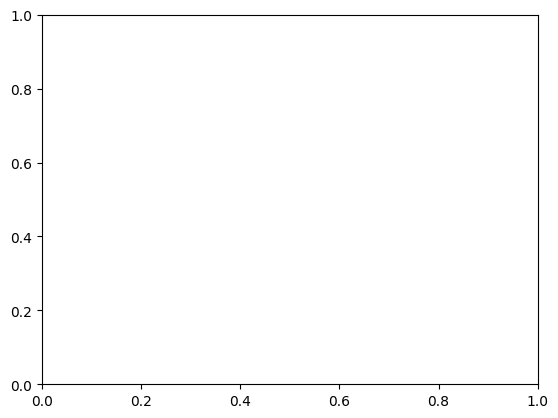

In [305]:
plt.plot(totalrho.cpu().numpy(),eps.cpu().detach().numpy())